In [9]:
# ===============================
# TITANIC DATA CLEANING PROJECT
# ===============================

# Step 1: Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [10]:
# Step 2: Load Dataset

df = pd.read_csv("Titanic-Dataset.csv")
print("Dataset Loaded Successfully\n")

Dataset Loaded Successfully



In [12]:
# Step 3: Explore Dataset

print("First 10 Rows")
print(df.head(10))

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


First 10 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy

In [13]:
# Step 4: Missing Values

print("\nMissing Values")
print(df.isnull().sum())


Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
# Step 5: Handle Missing Data

# Fill Age with Median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with Mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin
df.drop(columns=["Cabin"], inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())



Missing Values After Cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [15]:
# Step 6: Remove Duplicates

duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)
print("Dataset Shape After Removing Duplicates:", df.shape)


Duplicate Rows: 0
Dataset Shape After Removing Duplicates: (891, 11)


In [16]:
# Step 7: Encode Categorical Variables

label = LabelEncoder()
df["Sex"] = label.fit_transform(df["Sex"])

# One Hot Encoding

df = pd.get_dummies(df,
                    columns=["Embarked"],
                    drop_first=True)

print("\nColumns After Encoding")
print(df.columns)


Columns After Encoding
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [17]:
# Step 8: Feature Scaling

scaler = StandardScaler()
numerical_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
print("\nScaling Completed")


Scaling Completed


In [18]:
# Step 9: Train Test Split

X = df.drop(columns=["Survived","Name","Ticket","PassengerId"])
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (712, 8)
Testing Data Shape: (179, 8)


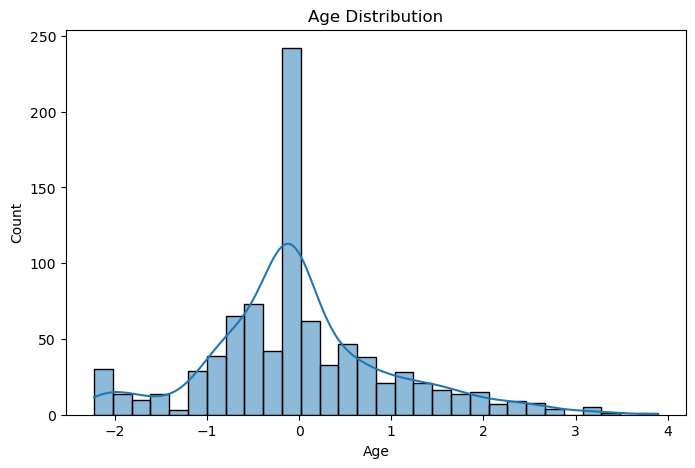

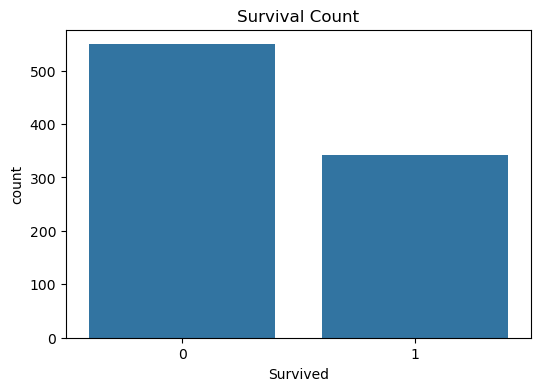

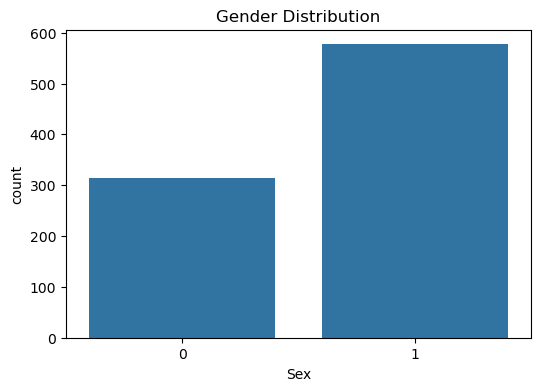

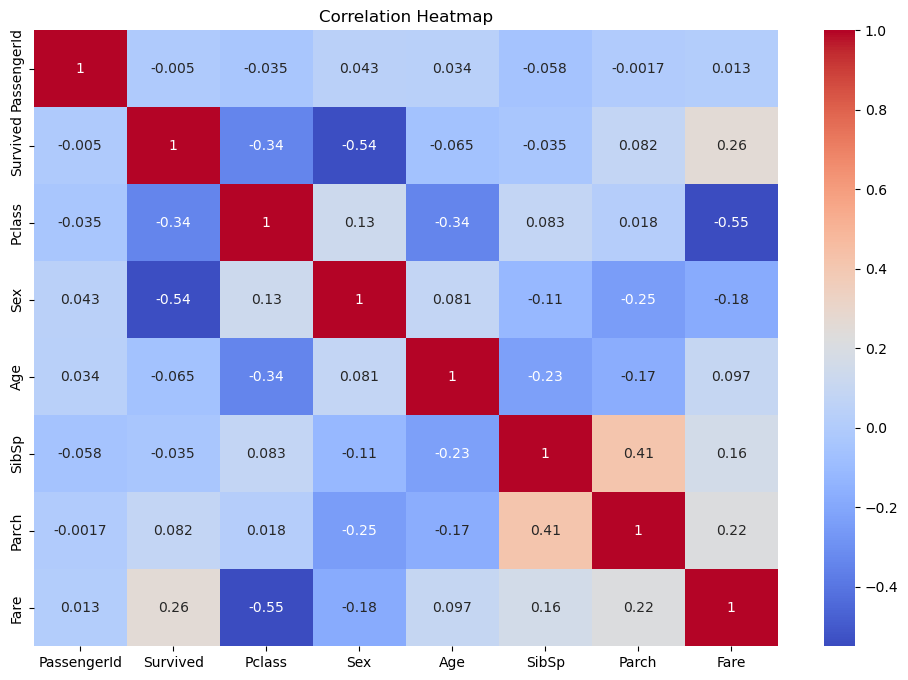

In [20]:
# Step 10: Visualizations

# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Survival Count

plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

# Gender Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

# Correlation Heatmap

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()


In [21]:
# Step 11: Save Cleaned Dataset

df.to_csv("Titanic_Cleaned.csv", index=False)
print("\nCleaned Dataset Saved Successfully")


Cleaned Dataset Saved Successfully


In [22]:
# Step 12: Final Dataset

print("\nFinal Dataset")
print(df.head())

print("\nFinal Shape")
print(df.shape)

print("\nFinal Missing Values")
print(df.isnull().sum())


Final Dataset
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex       Age     SibSp  \
0                            Braund, Mr. Owen Harris    1 -0.565736  0.432793   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  0.663861  0.432793   
2                             Heikkinen, Miss. Laina    0 -0.258337 -0.474545   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.433312  0.432793   
4                           Allen, Mr. William Henry    1  0.433312 -0.474545   

      Parch            Ticket      Fare  Embarked_Q  Embarked_S  
0 -0.473674         A/5 21171 -0.502445       False        True  
1 -0.473674          PC 17599  0.786845       False       False  
2 -0.473674  STON/O2. 3101282 -0.488854       False        True  
3 -0.473674      